# Descriptive analysis of green & brown employment based on EU-LFS data
Felix Zaussinger | 26.08.2022

**Core Analysis Goal(s)**
1. Create industry and regional plots based on final GBN classification (weighted and unweighted)
2. Create those plots both in an absolute and relative way

**Key Insight(s)**
1. Absolute numbers for unweighted shares closely correspond to independent figures of green employment based on EGSS data
2.
3.

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("paper")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

In [2]:
# preprocessing flag
reprocess = False

In [3]:
from src.data.framework import Esco

esco = Esco()

#### Read unweighted GBN shares at ISCO 3-digit level
The list makes sense for ISCO 3-digit occupations, even in the unweighted form!

In [7]:
gbn_shares_no_wt = esco.read_gbn_classification(agg_to_isco_at_digit=3)

gbn_shares_no_wt = gbn_shares_no_wt.rename(
    columns={"preferredLabel_isco": "ISCO3D_label"}
)
gbn_shares_no_wt["NOBS"] = 1
gbn_shares_no_wt

gbn_classification_short_list,isco_code,ISCO3D_label,share_green,share_brown_sl,share_neutral_sl,share_brown_slt,share_neutral_slt,NOBS
0,011,Commissioned armed forces officers,0.00,0.0,1.00,0.0,1.00,1
1,021,Non-commissioned armed forces officers,0.00,0.0,1.00,0.0,1.00,1
2,031,"Armed forces occupations, other ranks",0.00,0.0,1.00,0.0,1.00,1
3,111,Legislators and senior officials,0.00,0.0,1.00,0.0,1.00,1
4,112,Managing directors and chief executives,0.00,0.0,1.00,0.0,1.00,1
...,...,...,...,...,...,...,...,...
120,941,Food preparation assistants,0.00,0.0,1.00,0.0,1.00,1
121,951,Street and related service workers,0.00,0.0,1.00,0.0,1.00,1
122,952,Street vendors (excluding food),0.00,0.0,1.00,0.0,1.00,1
123,961,Refuse workers,0.75,0.0,0.25,0.0,0.25,1


#### Prepare EU-LFS data

In [6]:
from src.data.lfs import EuLfs
from src.data.framework import Classifications

# for NACE labels
classifications = Classifications()
covariates_by_nace = classifications.nace_1d

# load config file of EU-LFS data
config = utils.load_config(os.path.join(useful_paths.config_dir, "eu_lfs_config.yml"))

# create object
lfs = EuLfs(config=config)

Pre-process data

Countries with data limitations:
•	ISCO-08 2D: BG, PL
•	ISCO-08 1D: MT
•	NUTS 1: UK
•	NUTS Suppressed: NL

Countries removed for ISCO-08 3D results:
- BG
- PL
- MT

Possibilities for dropping observations:
- ISCO not coded at 3D (but at 2 or 1D)
- COEFF is NAN
- ISCO3D is 633 (subsistence farming --> investigate: https://esco.ec.europa.eu/en/classification/occupation?uri=http://data.europa.eu/esco/isco/C633)

In [7]:
countries_isco3d = [
    "AT",
    "BE",
    "CH",
    "CY",
    "CZ",
    "DE",
    "DK",
    "EE",
    "ES",
    "FI",
    "FR",
    "GR",
    "HR",
    "HU",
    "IE",
    "IS",
    "IT",
    "LT",
    "LU",
    "LV",
    "NL",
    "NO",
    "PT",
    "RO",
    "SE",
    "SK",
    "UK",
]

In [8]:
if reprocess:
    lfs.preprocess_files(
        years=[2019],
        countries=countries_isco3d,
        save_file=True,
        optional_output_dir=config["paths"]["interim"],
        output_fname="eu_lfs_merged_{year}",
    )

Join final unweighted shares

In [9]:
if reprocess:
    lfs.join_covariates(
        year=2019,
        optional_input_dir=config["paths"]["interim"],
        input_fname_lfs="eu_lfs_merged_{year}",
        covariates_by_isco=gbn_shares_no_wt,
        covariates_by_nace=covariates_by_nace,
        optional_output_dir=config["paths"]["interim"],
        output_fname_lfs="eu_lfs_merged_{year}_with_final_unweighted_shares",
        isco_covariate_selection=None,
    )

Aggregate data by regions, industries and occupations

In [10]:
# aggregate
agg_dict = {
    "COEFF": np.sum,
    "NOBS": np.sum,
    "COEFF_share_green": np.sum,
    "COEFF_share_brown_sl": np.sum,
    "COEFF_share_brown_slt": np.sum,
}

if reprocess:
    # by 1-digit industry
    lfs.aggregate(
        year=2019,
        group_by=["NACE1D_label"],
        agg_dict=agg_dict,
        input_fname="eu_lfs_merged_{year}_with_final_unweighted_shares",
        output_fname="eulfs_{year}_by_{by}_final_unweighted_shares",
    )

    # by 1-digit industry and country
    lfs.aggregate(
        year=2019,
        group_by=["NACE1D_label", "COUNTRYW"],
        agg_dict=agg_dict,
        input_fname="eu_lfs_merged_{year}_with_final_unweighted_shares",
        output_fname="eulfs_{year}_by_{by}_final_unweighted_shares",
    )

    # by nuts-2 regions and 1-digit industries
    lfs.aggregate(
        year=2019,
        group_by=["NUTS_ID", "NACE1D_label"],
        agg_dict=agg_dict,
        input_fname="eu_lfs_merged_{year}_with_final_unweighted_shares",
        output_fname="eulfs_{year}_by_{by}_final_unweighted_shares",
    )


#### Incorporate publication guidelines by Eurostat (thresholds for sample sizes, etc.)

In all reports, including both published and unpublished papers, three thresholds related to cell size will be distinguished for LFS results:
- Confidentiality threshold - below three observations (unweighted sample), results must not be published;
- Reliability thresholds - regarding reliability restrictions, Eurostat defines two limits, called 'a' and 'b'. Reliability limits depend on the sample size and design in the individual Member States.
    - Estimates corresponding to a (weighted) population below limit 'a' must not be published;
    - Estimates corresponding to a (weighted) population between limit 'a' and limit ‘b’ may be published with a warning concerning their limited reliability. This applies to quarterly data, annual averages of quarterly data, yearly data and ad hoc module results. The limits vary across Member States, years, and type of dataset. The thresholds “a” and “b” are provided in the CSV files in the “datafileinfo” folders in the anonymised microdata releases. More information can be found also at the LFS Statistics Explained pages, section “Publication guidelines and thresholds”.

See: C:\eurostat_data\raw\Yearly_Data\YearlyFiles_83_2019\_YearlyFiles\datafileinfo

In [11]:
threshold_a = 3

### Visualisation

In [12]:
from src.visualization.visualize import EulfsVis

config_paths = "paths_config.yml"
config_data = "data_config.yml"
config_vis = "vis_config.yml"

# EU-LFS
eulfs_visualiser = EulfsVis(
    fn_config_data=config_data,
    fn_config_path=config_paths,
    fn_vis_config=config_vis,
    year=2019,
)

Assign final data panel to visualisation class

In [13]:
data_panel_new = pd.read_pickle(
    os.path.join(
        config["paths"]["interim"],
        "eu_lfs_merged_{year}_with_final_unweighted_shares.pkl".format(year=2019),
    )
)
data_panel_new = data_panel_new.dropna(subset=["COEFF", "ISCO3D_label"])
eulfs_visualiser.data_panel = data_panel_new

Define cols to process and plot

In [14]:
cols_to_calc = [
    "COEFF_share_green",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
]

cols_to_aggregate = [
    "COEFF",
    "COEFF_share_green",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
]

cols_to_plot = [
    "COEFF_share_green_relative",
    "COEFF_share_brown_sl_relative",
    "COEFF_share_brown_slt_relative",
]

eulfs_visualiser.cols_to_calc_all = cols_to_aggregate
eulfs_visualiser.cols_to_calc = cols_to_calc

#### Plot (by industry)

In [15]:
eulfs_visualiser.create_industry_boxplots(
    year=2019,
    cols_to_aggregate=cols_to_aggregate,
    cols_to_plot=cols_to_plot,
    grouping=["NACE1D_label", "COUNTRYW"],
    out_dir=os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "{year}",
        "employment_shares_by_industry",
    ),
)

INFO:src.visualization.visualize:GBN employment shares by industry.
plotting variable: COEFF_share_green_relative
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   NACE1D_label                    567 non-null    object  
 1   COUNTRYW                        567 non-null    category
 2   COEFF                           567 non-null    float64 
 3   COEFF_share_green               567 non-null    float64 
 4   COEFF_share_brown_sl            567 non-null    float64 
 5   COEFF_share_brown_slt           567 non-null    float64 
 6   COEFF_relative                  564 non-null    float64 
 7   COEFF_share_green_relative      564 non-null    float64 
 8   COEFF_share_brown_sl_relative   564 non-null    float64 
 9   COEFF_share_brown_slt_relative  564 non-null    float64 
dtypes: category(1), float64(8), obje

In [16]:
eulfs_visualiser.create_industry_boxplots(
    year=2019,
    cols_to_aggregate=cols_to_aggregate,
    cols_to_plot=cols_to_plot,
    grouping=["NACE1D_label"],
    out_dir=os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "{year}",
        "employment_shares_by_industry",
        "grouped_by_industry_only",
    ),
)

INFO:src.visualization.visualize:GBN employment shares by industry.
plotting variable: COEFF_share_green_relative
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1402491 entries, 0 to 1417931
Data columns (total 38 columns):
 #   Column                          Non-Null Count    Dtype   
---  ------                          --------------    -----   
 0   AGE                             1402491 non-null  category
 1   COEFF                           1402491 non-null  float64 
 2   COEFF_share_brown_sl            1402491 non-null  float64 
 3   COEFF_share_brown_slt           1402491 non-null  float64 
 4   COEFF_share_green               1402491 non-null  float64 
 5   COEFF_share_neutral_sl          1402491 non-null  float64 
 6   COEFF_share_neutral_slt         1402491 non-null  float64 
 7   COUNTRY                         1402491 non-null  category
 8   COUNTRYW                        1402491 non-null  category
 9   DEGURBA                         1402491 non-null  category
 10  

#### Plot (by region)

In [17]:
# eulfs_visualiser.create_maps(
#     slice_by_industry=False,
#     vmin=0,
#     vmax=0.03,
#     cmap="Greys",
#     n_cats=3,
#     out_dir=os.path.join(
#             useful_paths.figure_dir,
#             "03_eulfs",
#             "2019",
#             "employment_shares_by_region",
#             "NEW",
#             "cbars_fixed_at_3_percent_discrete"
#         ),
# )

In [18]:
# eulfs_visualiser.create_maps(
#     slice_by_industry=True,
#     vmin=0,
#     vmax=None,
#     cmap="Greys",
#     n_cats=None,
#     out_dir=os.path.join(
#             useful_paths.figure_dir,
#             "03_eulfs",
#             "2019",
#             "employment_shares_by_region",
#             "NEW",
#             "by_industry"
#         ),
# )

Bar charts by country

In [19]:
agg = {
    "NOBS": np.sum,
    "COEFF": np.sum,
    "COEFF_share_brown_sl": np.sum,
    "COEFF_share_brown_slt": np.sum,
    "COEFF_share_green": np.sum,
    "COEFF_share_neutral_sl": np.sum,
    "COEFF_share_neutral_slt": np.sum,
}

data_agg = data_panel_new.groupby(["COUNTRYW", "NACE1D_label"]).aggregate(agg)

# calculate relative shares at regional level
for col in data_agg.columns[data_agg.columns.str.startswith("COEFF_")]:
    data_agg["{}_relative".format(col)] = data_agg[col] / data_agg["COEFF"]

In [20]:
data_agg_final = data_agg[data_agg["NOBS"] >= threshold_a]

#### Plots by industry (w/o country grouping)

In [21]:
df = data_panel_new
for col in cols_to_aggregate:
    df["{}_relative".format(col)] = df[col] / df["COEFF"]

df

,AGE,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRY,COUNTRYW,DEGURBA,EDUC4WN,FTPT,HATLEV1D,HHTYPE,ILOSTAT,INCDECIL,ISCO,ISCO3D,ISCO3D_label,MAINSTAT,NACE1D,NACE1D_label,NOBS,NUTS_ID,REFYEAR,REGION,REGIONW,SEX,WSTATOR,share_brown_sl,share_brown_slt,share_green,share_neutral_sl,share_neutral_slt,COEFF_relative,COEFF_share_green_relative,COEFF_share_brown_sl_relative,COEFF_share_brown_slt_relative
0,52,82.5525,2.79839,1.399195,0.000000,79.754110,81.153305,AT,AT,3,0,1,M,1,1,NaN,132,132,"Manufacturing, mining, construction, and distr...",1,C,Manufacturing,1.0,AT12,2019,10,12,1,1,0.033898,0.016949,0.000000,0.966102,0.983051,1.0,0.000000,0.033898,0.016949
1,17,82.5525,0.00000,0.000000,8.008825,74.543675,74.543675,AT,AT,3,1,1,L,1,1,NaN,311,311,Physical and engineering science technicians,1,G,Wholesale and Retail Trade; Repair of Motor Ve...,1.0,AT12,2019,10,12,1,1,0.000000,0.000000,0.097015,0.902985,0.902985,1.0,0.097015,0.000000,0.000000
2,42,47.2325,0.00000,0.000000,0.000000,47.232500,47.232500,AT,AT,3,0,1,M,1,1,NaN,411,411,General office clerks,1,G,Wholesale and Retail Trade; Repair of Motor Ve...,1.0,AT12,2019,10,12,2,1,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,0.000000,0.000000,0.000000
3,47,52.9450,0.00000,0.000000,0.000000,52.945000,52.945000,AT,AT,3,0,1,M,1,1,NaN,911,911,"Domestic, hotel and office cleaners and helpers",1,Q,Human Health and Social Work Activities,1.0,AT12,2019,10,12,2,1,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,0.000000,0.000000,0.000000
4,42,75.8625,0.00000,0.000000,0.000000,75.862500,75.862500,AT,AT,2,0,1,H,1,1,NaN,265,265,Creative and performing artists,1,R,"Arts, Entertainment and Recreation",1.0,AT12,2019,10,12,2,1,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1417927,17,1100.1400,0.00000,0.000000,0.000000,1100.140000,1100.140000,UK,UK,1,1,2,M,1,1,NaN,421,421,"Tellers, money collectors and related clerks",NaN,G,Wholesale and Retail Trade; Repair of Motor Ve...,1.0,UKM,2019,M0,M0,1,2,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,0.000000,0.000000,0.000000
1417928,52,1790.6100,246.98069,61.745172,370.471034,1173.158276,1358.393793,UK,UK,3,0,1,H,1,1,10,211,211,Physical and earth science professionals,NaN,O,Public Administration and Defence; Compulsory ...,1.0,UKM,2019,M0,M0,1,1,0.137931,0.034483,0.206897,0.655172,0.758621,1.0,0.206897,0.137931,0.034483
1417929,57,1858.6800,0.00000,0.000000,168.970909,1689.709091,1689.709091,UK,UK,2,0,1,M,1,1,NaN,833,833,Heavy truck and bus drivers,NaN,H,Transportation and Storage,1.0,UKM,2019,M0,M0,1,1,0.000000,0.000000,0.090909,0.909091,0.909091,1.0,0.090909,0.000000,0.000000
1417930,57,1723.3000,0.00000,0.000000,0.000000,1723.300000,1723.300000,UK,UK,2,0,1,H,1,1,06,263,263,Social and religious professionals,NaN,Q,Human Health and Social Work Activities,1.0,UKM,2019,M0,M0,2,1,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,0.000000,0.000000,0.000000


Diskussion mit Flo bzgl Medianen in diesem Plot:
- es macht Sinn, das 50% aller Jobs über alle Länder in einem der Sektoren total neutral sind
- deshalb sind die Mediane auch grossteils gleich null

NACE1D_label
Accommodation and Food Service Activities                                                                                    0.000000
Activities of Extraterritorial Organisations and Bodies                                                                      0.000000
Activities of Households as Employers; Undifferentiated Goods and Services Producing Activities of Households for Own Use    0.000000
Administrative and Support Service Activities                                                                                0.000000
Agriculture, Forestry and Fishing                                                                                            0.000000
Arts, Entertainment and Recreation                                                                                           0.000000
Construction                                                                                                                 0.000000
Education                                        

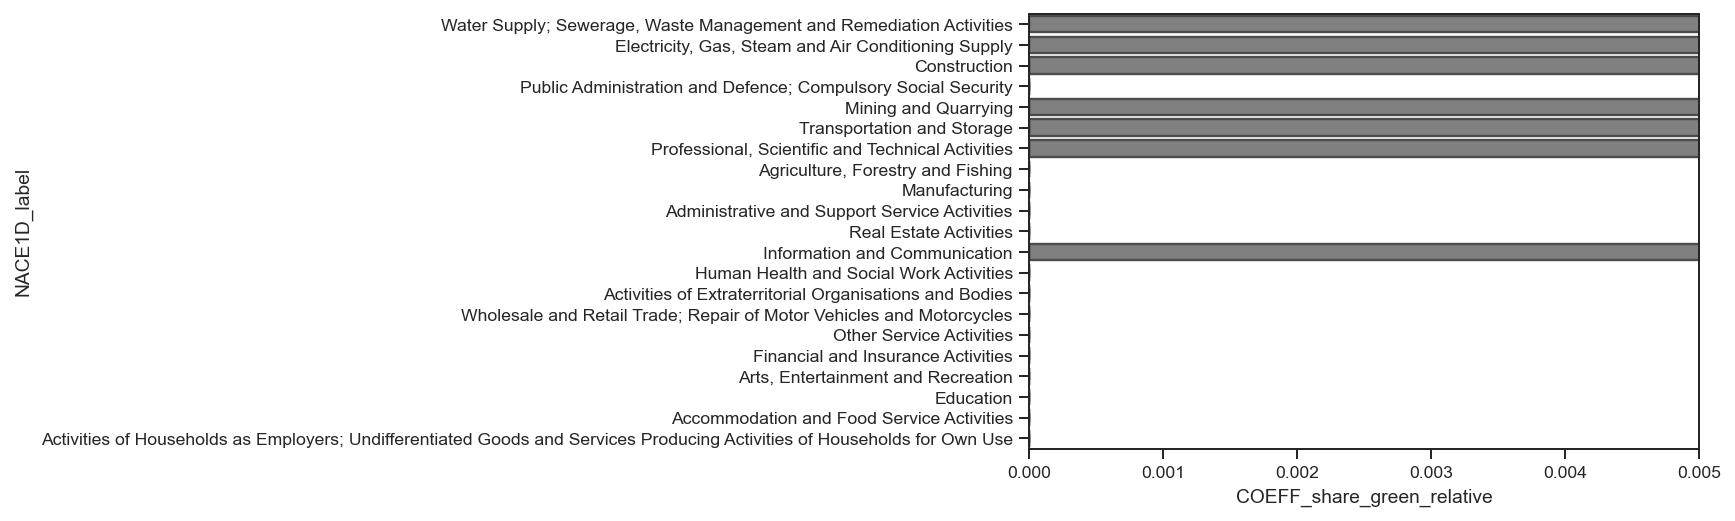

In [22]:
x = "COEFF_share_green_relative"
y = "NACE1D_label"

ax = sns.boxplot(
    data=df,
    x=x,
    y=y,
    order=df.groupby(y)[x].mean().sort_values(ascending=False).index.values,
    color=".5",
    fliersize=1,
    showfliers=True,
)

ax.set_xlim(0, 0.005)

df.groupby(y)[x].median()

Bar plots to also show absolute numbers

<AxesSubplot:xlabel='COEFF', ylabel='NACE1D_label'>

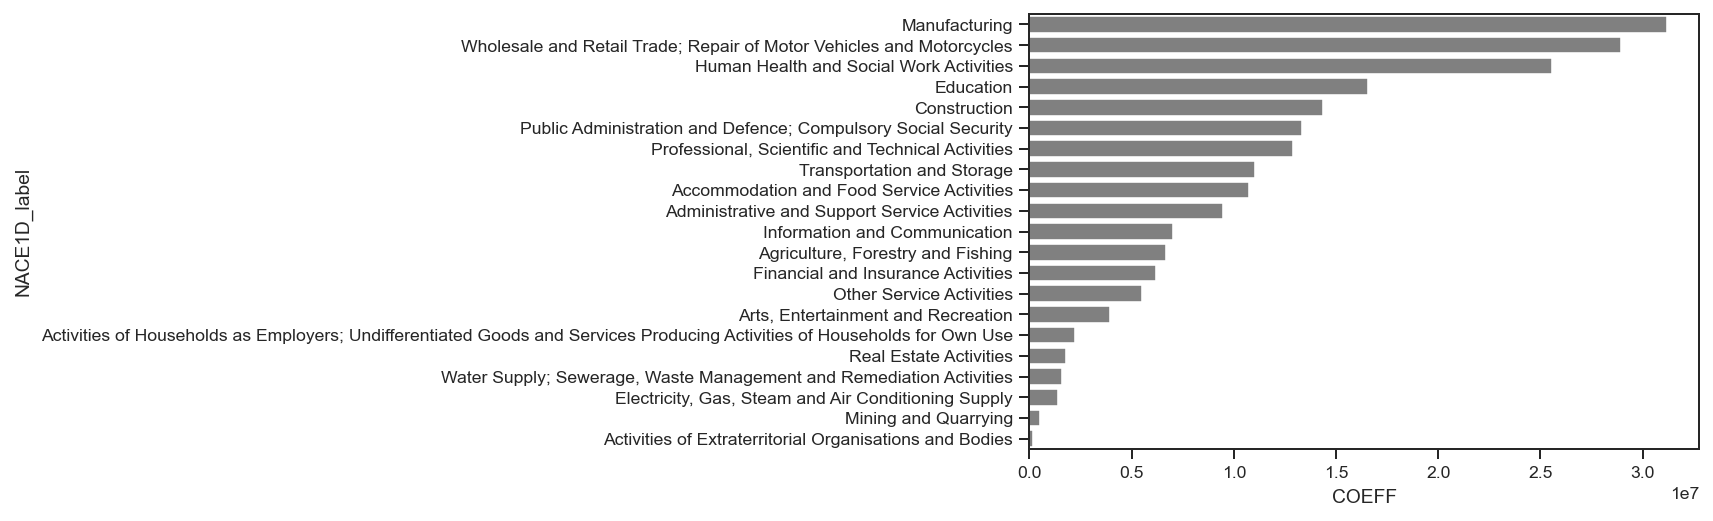

In [23]:
x = "COEFF"
y = "NACE1D_label"

sns.barplot(
    data=df,
    x=x,
    y=y,
    order=df.groupby(y)[x].sum().sort_values(ascending=False).index.values,
    estimator=np.sum,
    ci=None,
    color="Grey",
)

Our estimate of 212.5 Million compares well with the [offical size of labour force](https://data.worldbank.org/indicator/SL.TLF.TOTL.IN?locations=EU), 217.8 Million (some countries are missing in our estimates).

In [24]:
df.COEFF.sum()

212469169.185

Absolute/relative COEFF by industry

In [67]:
x_vars = [
    "COEFF_share_green",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
    "COEFF_share_neutral_sl",
    "COEFF_share_neutral_slt",
]
y = "NACE1D_label"

for x in x_vars:

    f, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(
        data=df,
        x=x,
        y=y,
        order=df.groupby(y)[x].sum().sort_values(ascending=False).index.values,
        estimator=np.sum,
        ci=None,
        color="Grey",
        ax=ax,
    )

    # calculate sector-level percentage
    order = df.groupby(y)[x].sum().sort_values(ascending=False).index
    sum_across_cnt_share = df.groupby(y)[x].sum()
    sum_across_cnt = df.groupby(y)["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    percentages = ind_share.reindex(order).multiply(100).round(1)
    percent_labels = ["{}%".format(l) for l in percentages]

    # show the percentage within sector
    ax.bar_label(ax.containers[0], labels=percent_labels, padding=1)

    ax.grid(axis="x", linestyle="--", zorder=0)
    sns.despine()
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            useful_paths.figure_dir,
            "03_eulfs",
            "2019",
            "employment_shares_by_industry",
            "grouped_by_industry_only",
            "{}_by_{}_absolute.png".format(x, y),
        ),
        dpi=150,
    )
    plt.clf()

<Figure size 720x504 with 0 Axes>

<Figure size 720x504 with 0 Axes>

<Figure size 720x504 with 0 Axes>

<Figure size 720x504 with 0 Axes>

<Figure size 720x504 with 0 Axes>

Absolute/relative COEFF by country

In [80]:
x_vars = [
    "COEFF_share_green",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
    "COEFF_share_neutral_sl",
    "COEFF_share_neutral_slt",
]
y = "COUNTRYW"

for x in x_vars:
    f, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(
        data=df,
        x=y,
        y=x,
        order=df.groupby(y)[x].sum().sort_values(ascending=False).index.values,
        estimator=np.sum,
        ci=None,
        color="Grey",
    )

    # calculate country-level percentage
    sum_across_cnt_share = df.groupby(y)[x].sum()
    sum_across_cnt = df.groupby(y)["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    order = sum_across_cnt_share.sort_values(ascending=False).index
    percentages = ind_share.reindex(order).multiply(100).round(1)
    percent_labels = ["{}%".format(l) for l in percentages]

    # show the percentage within sector
    ax.bar_label(ax.containers[0], labels=percent_labels, padding=1)

    ax.ticklabel_format(useOffset=False, style="plain", axis="y")
    ax.grid(axis="y", linestyle="--", zorder=0)
    sns.despine()
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            useful_paths.figure_dir,
            "03_eulfs",
            "2019",
            "employment_shares_by_country",
            "{}_by_{}_absolute.png".format(x, y),
        ),
        dpi=150,
    )
    plt.close(f)

Absolute/relative COEFF by sociodemographics (DEGURBA, HATLEV1D, SEX)

In [81]:
x_vars = [
    "COEFF_share_green",
    "COEFF_share_brown_sl",
    "COEFF_share_brown_slt",
    "COEFF_share_neutral_sl",
    "COEFF_share_neutral_slt",
]
y = "SEX"

for x in x_vars:
    f, ax = plt.subplots(figsize=(10, 7))
    sns.barplot(data=df, x=y, y=x, order=None, estimator=np.sum, ci=None, color="Grey")

    # calculate country-level percentage
    sum_across_cnt_share = df.groupby(y)[x].sum()
    sum_across_cnt = df.groupby(y)["COEFF"].sum()
    ind_share = sum_across_cnt_share.divide(sum_across_cnt)
    order = sum_across_cnt_share.sort_values(ascending=False).index
    percentages = ind_share.reindex(order).multiply(100).round(1)
    percent_labels = ["{}%".format(l) for l in percentages]

    # show the percentage within sector
    ax.bar_label(ax.containers[0], labels=percent_labels, padding=1)

    ax.ticklabel_format(useOffset=False, style="plain", axis="y")
    ax.grid(axis="y", linestyle="--", zorder=0)
    sns.despine()
    plt.tight_layout()
    out_dir = os.path.join(
        useful_paths.figure_dir, "03_eulfs", "2019", "employment_by_{}".format(y)
    )
    utils.ccdir(out_dir)
    fname = "{}_by_{}_absolute.png".format(x, y)
    plt.savefig(os.path.join(out_dir, fname), dpi=150)
    plt.close(f)

Absolute/relative COEFF at EU level

COEFF_share_green 4208827.447783261
COEFF_share_brown_sl 6197215.803485268
COEFF_share_brown_slt 2308459.231358477
COEFF_share_neutral_sl 202063125.93373165
COEFF_share_neutral_slt 205951882.5058582


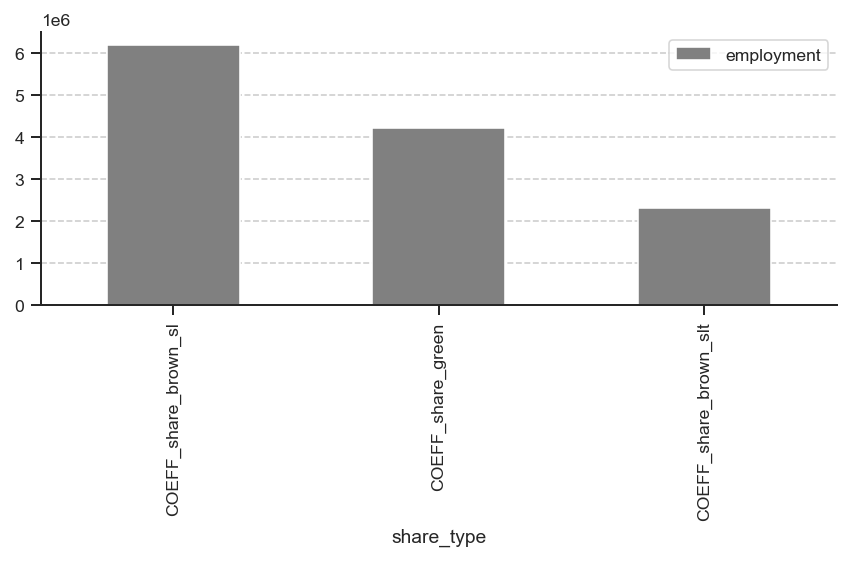

In [39]:
res = []
for x in x_vars:
    sum_total = df[x].sum()
    print(x, sum_total)
    res.append([x, sum_total])

df_res = pd.DataFrame(res, columns=["share_type", "employment"])
df_res = df_res.set_index("share_type")
ax = (
    df_res.iloc[0:3, :]
    .sort_values(by="employment", ascending=False)
    .plot.bar(color="grey")
)

ax.grid(axis="y", linestyle="--", zorder=0)
sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "EU_employment_by_share_type_absolute.png".format(x, y),
    ),
    dpi=300,
)

df_res.to_csv(
    os.path.join(
        useful_paths.figure_dir,
        "03_eulfs",
        "2019",
        "employment_shares_by_country",
        "EU_employment_by_share_type_absolute.csv",
    ),
)

In [59]:
df_res_sl = df_res.loc[
    ("COEFF_share_green", "COEFF_share_brown_sl", "COEFF_share_neutral_sl"), :
]
df_res_sl.divide(df_res_sl.sum()) * 100

,employment
share_type,
COEFF_share_green,1.980912
COEFF_share_brown_sl,2.916760
COEFF_share_neutral_sl,95.102328


In [60]:
df_res_slt = df_res.loc[
    ("COEFF_share_green", "COEFF_share_brown_slt", "COEFF_share_neutral_slt"), :
]
df_res_slt.divide(df_res_slt.sum()) * 100

,employment
share_type,
COEFF_share_green,1.980912
COEFF_share_brown_slt,1.086491
COEFF_share_neutral_slt,96.932597


#### Shares by sociodemographic variables

Degree of urbanisation (DEGURBA)

1 Cities (Densely-populated area)
2 Towns and suburbs (Intermediate density area)
3 Rural area (Thinly-populated area)

Gender (SEX)

1 Male
2 Female

Level of education
L Low: Lower secondary
M Medium: Upper secondary
H High: Third level

In [30]:
x_vars = ["share_green", "share_brown_sl", "share_brown_slt"]
y = "NACE1D_label"
hues = ["HATLEV1D", "DEGURBA", "SEX"]
hue_orders = [["H", "M", "L"], ["1", "2", "3"], ["1", "2"]]

for x in x_vars:
    for hue, hue_order in zip(hues, hue_orders):
        f, ax = plt.subplots(figsize=(10, 7))
        sns.pointplot(
            data=df,
            x=x,
            y=y,
            hue=hue,
            hue_order=hue_order,
            order=df.groupby(y)[x].mean().sort_values(ascending=False).index.values,
            color=".5",
            ci="sd",
            join=False,
            dodge=0.5,
            errwidth=1,
            # capsize=0.5,
            scale=0.7,
        )

        ax.set_xlim(0, 0.7)
        ax.grid(axis="x", linestyle="--", zorder=0)
        sns.despine()

        plt.tight_layout()
        plt.savefig(
            os.path.join(
                useful_paths.figure_dir,
                "03_eulfs",
                "2019",
                "employment_shares_by_industry",
                "grouped_by_industry_only",
                "{}_by_{}_and_{}.png".format(x, y, hue),
            ),
            dpi=150,
        )
        plt.close(f)

NOTE:
`share_green` precisely equals `COEFF_share_green_relative`

In [31]:
np.isclose(df.share_green, df.COEFF_share_green_relative).all()

True

In [32]:
df.groupby("DEGURBA").describe()

COEFF                                                    \
            count        mean         std    min      25%       50%   
DEGURBA                                                               
1        467091.0  192.412330  273.349589  0.050  59.0775  112.8325   
2        490992.0  146.440306  190.343314  1.205  49.8750   99.4400   
3        444408.0  114.071041  179.634094  0.850  33.7050   62.8000   

                            COEFF_share_brown_sl                            \
               75%      max                count      mean        std  min   
DEGURBA                                                                      
1        185.02125  9819.63             467091.0  3.936882  26.510872  0.0   
2        165.19000  7443.77             490992.0  5.023321  26.381366  0.0   
3        136.29250  8690.64             444408.0  4.257176  26.700183  0.0   

                                    COEFF_share_brown_slt                      \
         25%  50%  75%          max                 count      mean       std   
DEGURBA                                                                         
1        0.0  0.0  0.0  2068.318421              467091.0  1.674041  9.819688   
2        0.0  0.0  0.0  1959.341522              490992.0  1.768730  8.237114   
3        0.0  0.0  0.0  4176.913846              444408.0  1.480840  9.005525   

                                      COEFF_share_green                       \
         min  25%  50%  75%       max             count      mean        std   
DEGURBA                                                                        
1        0.0  0.0  0.0  0.0  1368.486          467091.0  3.505288  19.057178   
2        0.0  0.0  0.0  0.0   720.920          490992.0  2.923094  15.296932   
3        0.0  0.0  0.0  0.0  2262.495          444408.0  2.556937  16.750595   

                                       COEFF_share_neutral_sl              \
         min  25%  50%  75%        max                  count        mean   
DEGURBA                                                                     
1        0.0  0.0  0.0  0.0  1672.5940               467091.0  184.970159   
2        0.0  0.0  0.0  0.0  2081.9325               490992.0  138.493890   
3        0.0  0.0  0.0  0.0  2871.8600               444408.0  107.256928   

                                                                     \
                std  min       25%         50%         75%      max   
DEGURBA                                                               
1        265.857165  0.0  55.78000  106.931400  179.043050  9819.63   
2        184.440226  0.0  45.64500   92.075000  157.760000  7443.77   
3        172.173992  0.0  31.26216   58.242519  126.875329  8690.64   

        COEFF_share_neutral_slt                                          \
                          count        mean         std  min        25%   
DEGURBA                                                                   
1                      467091.0  187.233000  267.322947  0.0  57.225000   
2                      490992.0  141.748481  185.889897  0.0  47.996244   
3                      444408.0  110.033264  174.435030  0.0  32.423763   

                                         NOBS                                \
              50%      75%      max     count mean  std  min  25%  50%  75%   
DEGURBA                                                                       
1        109.1725  180.425  9819.63  467091.0  1.0  0.0  1.0  1.0  1.0  1.0   
2         95.9600  159.975  7443.77  490992.0  1.0  0.0  1.0  1.0  1.0  1.0   
3         60.4500  130.435  8690.64  444408.0  1.0  0.0  1.0  1.0  1.0  1.0   

             share_brown_sl                           ... share_brown_slt  \
         max          count      mean       std  min  ...             25%   
DEGURBA                                               ...                   
1        1.0       467091.0  0.021457  0.088690  0.0  ...             0.0   
2        1.0       49099

<AxesSubplot:xlabel='DEGURBA', ylabel='share_brown_sl'>

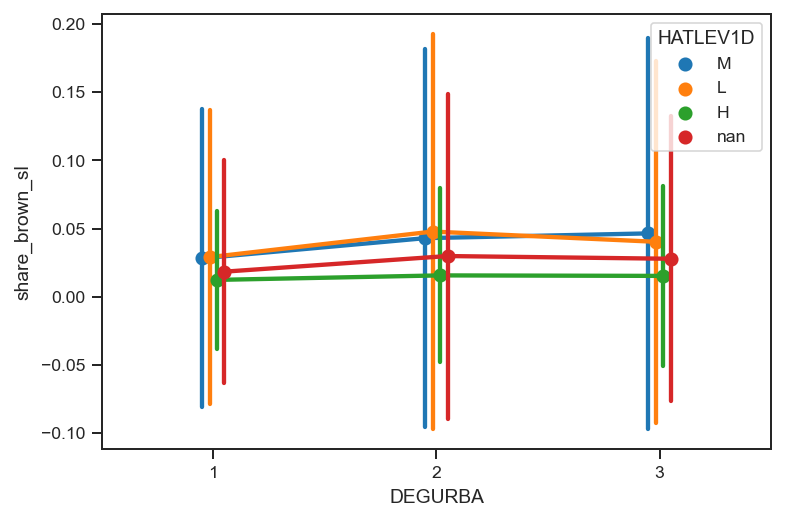

In [33]:
group_var = "DEGURBA"
num_var = "share_brown_sl"
# sns.boxplot(x=df[group_var].astype(int), y=df[num_var])
sns.pointplot(
    x=df[group_var].astype(int),
    y=df[num_var],
    hue=df["HATLEV1D"].astype(str),
    ci="sd",
    dodge=True,
)

<AxesSubplot:xlabel='HATLEV1D', ylabel='share_green'>

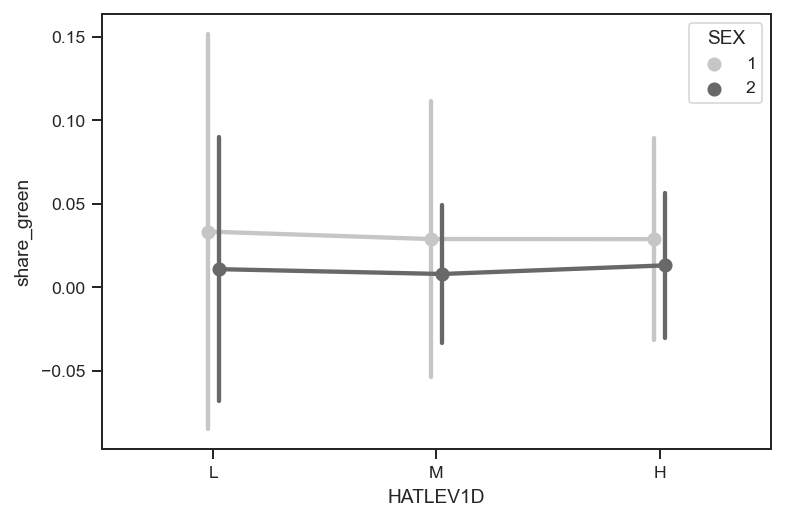

In [34]:
x = "HATLEV1D"
y = "share_green"
hue = "SEX"
order = ["L", "M", "H"]
df2 = df.dropna(subset=[x])
sns.pointplot(
    x=df2[x].astype(str),
    y=df2[y],
    hue=df2[hue],
    dodge=True,
    palette="Greys",
    ci="sd",
    order=order,
)

In [35]:
def weighted_mean(x):
    np.average(x, weights=x.COEFF)

In [36]:
df.groupby("DEGURBA").aggregate({"share_brown_sl": weighted_mean})

AttributeError: 'Series' object has no attribute 'COEFF'